In [21]:
import torch
from torch import nn

import seaborn as sns

from Model_FullBNN import FullBNN

# define constants
model_name = FullBNN.__name__
model_save_path = f"data/model_weights/{model_name}.pnn"

In [22]:
# Now load the model
model = FullBNN()
state_dict = torch.load(model_save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [23]:
model

FullBNN(
  (preprocess): Sequential(
    (0): LearnableShift()
    (1): QuantizeBinary()
  )
  (features): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): BinaryConv2d()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): QuantizeBinary()
    (4): BinaryConv2d()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): BinaryLinear()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1028, out_features=10, bias=True)
  )
)

In [24]:
params = model.preprocess.parameters()
list(params)

[Parameter containing:
 tensor(0.4494, requires_grad=True)]

In [41]:
bin_conv_layer = model.features[4]
params = bin_conv_layer.get_parameter("weights")

tensor([ 2.2345e-01,  1.1430e-01, -1.1233e-04,  ...,  1.9357e-01,
         1.4705e-01,  1.5699e-01], grad_fn=<ViewBackward0>)

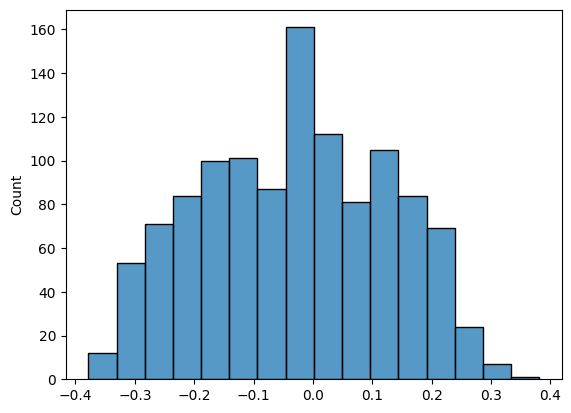

In [42]:
w = params.flatten()
sns.histplot(w.detach().numpy())
w

In [89]:
state_dict["features.1.weights"].shape

torch.Size([8, 1, 3, 3])

In [90]:
for w_index in ["features.1.weights", "features.4.weights", "classifier.2.weight", "classifier.2.bias"]:
  state_dict[w_index] = torch.sign(state_dict[w_index])

In [99]:
model.load_state_dict(state_dict)

<All keys matched successfully>

In [106]:
# Now with binarized weights loaded, we go off to incorporate
from func.validate_model import validate_model
from func.load_mnist import load_mnist

criterion = torch.nn.CrossEntropyLoss()
_, mnist_dataloader = load_mnist()
validate_model(model, criterion, mnist_dataloader, torch.device("cpu"))

ValidateModelRecord(normalized_loss=0.00041194241046905517, total_accuracy=0.7528)